In [ ]:
%pip install transformers

In [1]:
import random
from io import BytesIO
from typing import (
    Collection,
    Literal,
    Mapping,
    Sequence,
    TypedDict,
    cast,
)

import requests
import torch
from IPython.display import display  # type: ignore
from PIL import Image, ImageDraw, ImageFont
from transformers import BatchFeature, DetrForObjectDetection, DetrImageProcessorFast


### Constants

Here we define a few constants that we will use, including the Huggingface model name

We also specify the `DEVICE_TO_USE` to run the model. If you have an NVIDIA GPU, you can change to `"cuda"`.


In [2]:
DETR_MODEL_NAME: Literal["facebook/detr-resnet-50", "facebook/detr-resnet-101"] = (
    "facebook/detr-resnet-101"
)

DEVICE_TO_USE: Literal["cpu", "cuda", "mps"] = "cpu"

### Load DETR models


In [3]:
detr_image_processor = DetrImageProcessorFast.from_pretrained(
    "facebook/detr-resnet-101", revision="no_timm"
)
detr_model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-101", revision="no_timm"
).eval()


### Fetch images for input


In [4]:
def get_images_from_urls(
    image_urls: list[str], long_edge_size: int | None = 1000
) -> Sequence[Image.Image]:
    def download_file(url: str) -> BytesIO:
        response = requests.get(url)
        response.raise_for_status()  # Ensure we notice bad responses
        return BytesIO(response.content)

    def resize_long_edge(
        image: Image.Image,
        long_edge_size: int,
    ) -> Image.Image:
        width, height = image.size
        if width > height:
            return image.resize((long_edge_size, int(height * long_edge_size / width)))
        else:
            return image.resize((int(width * long_edge_size / height), long_edge_size))

    images = [Image.open(download_file(image_url)) for image_url in image_urls]

    if long_edge_size is not None:
        images = [resize_long_edge(image, long_edge_size) for image in images]

    return images


def get_input_for_inference(
    detr_image_processor: DetrImageProcessorFast,
    pil_images: Collection[Image.Image],
) -> BatchFeature:
    """
    This function takes a list of PIL images and returns the transformed images and the reverse transform.
    """
    return detr_image_processor.preprocess(images=list(pil_images), return_tensors="pt")

In [5]:
IMAGE_URLS = [
    "https://dragoneye-public.s3.us-east-1.amazonaws.com/sample_images/animals/petting_zoo.jpeg",
    "https://dragoneye-public.s3.us-east-1.amazonaws.com/sample_images/vehicles_and_transportation/5.jpg",
    "https://dragoneye-public.s3.us-east-1.amazonaws.com/sample_images/sports_equipment/8.jpg",
    "https://dragoneye-public.s3.us-east-1.amazonaws.com/sample_images/vehicles_and_transportation/1.jpg",
    "https://dragoneye-public.s3.us-east-1.amazonaws.com/demo-images/household_items/full-size/1.webp",
]

input_images = get_images_from_urls(IMAGE_URLS)
input_features = get_input_for_inference(
    detr_image_processor=detr_image_processor, pil_images=input_images
).to(DEVICE_TO_USE)

### Run the images through the YOLO model


In [6]:
class ModelResult(TypedDict):
    scores: torch.Tensor
    labels: torch.Tensor
    boxes: torch.Tensor


with torch.no_grad():
    outputs = detr_model(**input_features)
    model_results = cast(
        list[ModelResult],
        detr_image_processor.post_process_object_detection(
            outputs=outputs,
            target_sizes=[
                (input_image.height, input_image.width) for input_image in input_images
            ],
        ),
    )


In [7]:
for idx, model_result in enumerate(model_results):
    print(f"Model Result - Image {idx} - {IMAGE_URLS[idx]}")
    print(f"{model_result}\n")

Model Result - Image 0 - https://dragoneye-public.s3.us-east-1.amazonaws.com/sample_images/animals/petting_zoo.jpeg
{'scores': tensor([0.9641, 0.7403, 0.5478, 0.7118, 0.9940, 0.8839, 0.7092, 0.9152, 0.9819,
        0.5937, 0.9864, 0.8944, 0.9687, 0.9826, 0.5573, 0.9974, 0.8594, 0.9318,
        0.9695, 0.6754, 0.9687]), 'labels': tensor([20, 20, 21, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
        20,  8, 20]), 'boxes': tensor([[ 5.9802e+02,  2.8047e+02,  7.6889e+02,  3.7950e+02],
        [ 6.7250e+02,  3.8329e+02,  9.6335e+02,  5.9444e+02],
        [ 1.9107e+02,  2.5395e+02,  4.8984e+02,  6.4179e+02],
        [ 8.8412e+02,  2.6383e+02,  9.5276e+02,  3.2354e+02],
        [ 1.9491e+02,  2.5201e+02,  4.8864e+02,  6.4675e+02],
        [ 7.4929e+02,  3.3480e+02,  9.7595e+02,  4.1870e+02],
        [ 6.9695e+01,  2.7816e+02,  1.6535e+02,  3.8588e+02],
        [ 7.4353e+02,  3.3774e+02,  9.5575e+02,  4.0541e+02],
        [ 2.7207e+01,  3.7613e+02,  2.4270e+02,  6.2272e+02],


### Visualize the object prediction results


In [8]:
def visualize_object_predictions(
    img: Image.Image,
    model_result: ModelResult,
    class_id_to_label: Mapping[int, str] | Sequence[str] | None,
    display_result: bool,
) -> Image.Image | None:
    img = img.copy()
    label_size = img.size[1] / 30
    draw = ImageDraw.Draw(img, "RGBA")

    font = ImageFont.load_default(int(label_size))

    for bbox, score, class_id in zip(
        model_result["boxes"],
        model_result["scores"],
        model_result["labels"],
    ):
        bbox = tuple(bbox.numpy(force=True))  # pyright: ignore [reportUnknownArgumentType]
        class_id = int(class_id)
        score = float(score)

        random.seed(class_id)
        color = (
            random.randint(0, 200),
            random.randint(0, 200),
            random.randint(0, 200),
        )

        draw.rounded_rectangle(bbox, outline=(*color, 200), radius=5, width=2)
        draw.rounded_rectangle(bbox, fill=(*color, 100), radius=5)

        class_text = class_id_to_label[class_id] if class_id_to_label else class_id
        label_text = f"{class_text} - {score: .0%}"

        text_bbox = font.getbbox(label_text)
        text_width = text_bbox[2] - text_bbox[0]
        text_height = (text_bbox[3] - text_bbox[1]) * 1.5

        x_min, y_min, _x_max, _y_max = bbox

        text_background = [
            (x_min, y_min),
            (x_min + text_width, y_min + text_height),
        ]
        draw.rounded_rectangle(text_background, fill=(*color, 175), radius=2)
        draw.text(
            (x_min, y_min),
            label_text,
            fill="white",
            font=font,
        )

    if display_result:
        display(img)
    else:
        return img


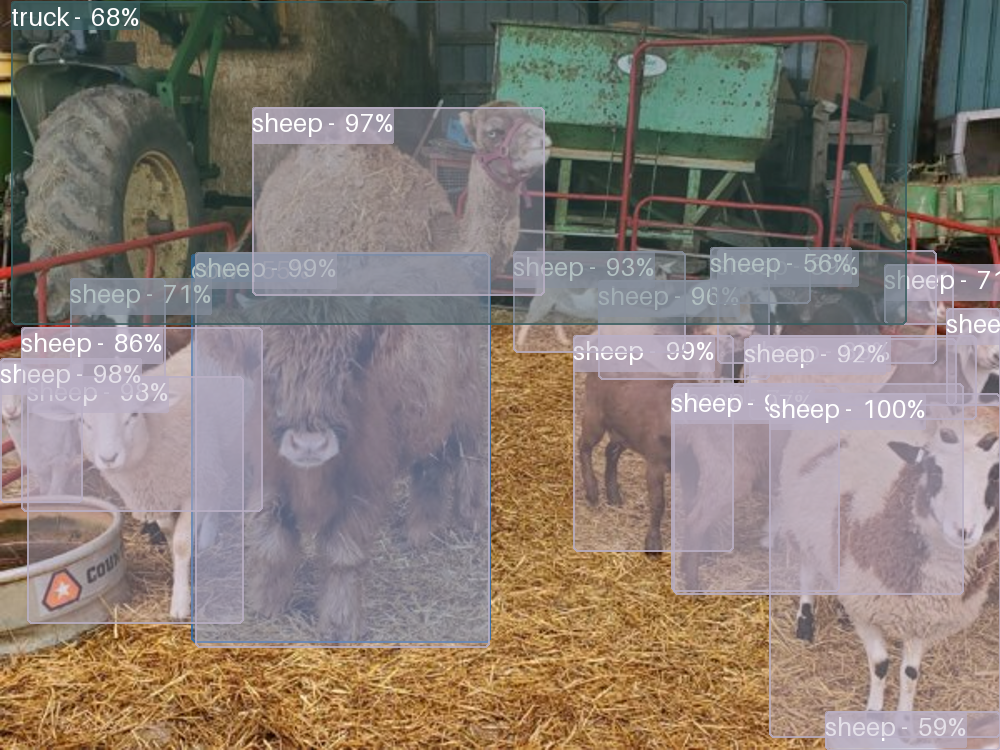

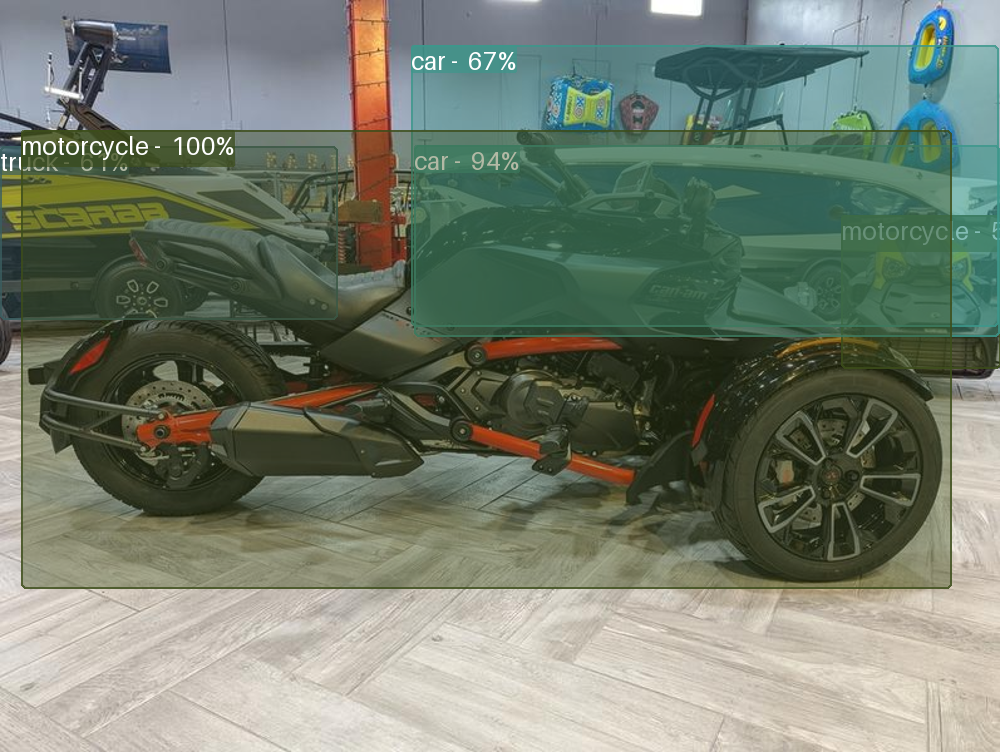

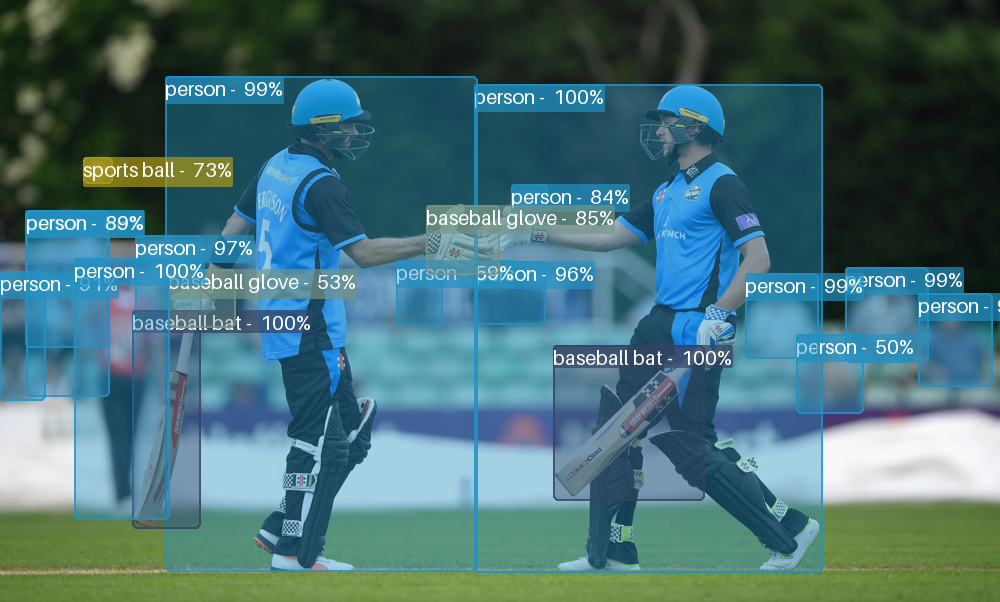

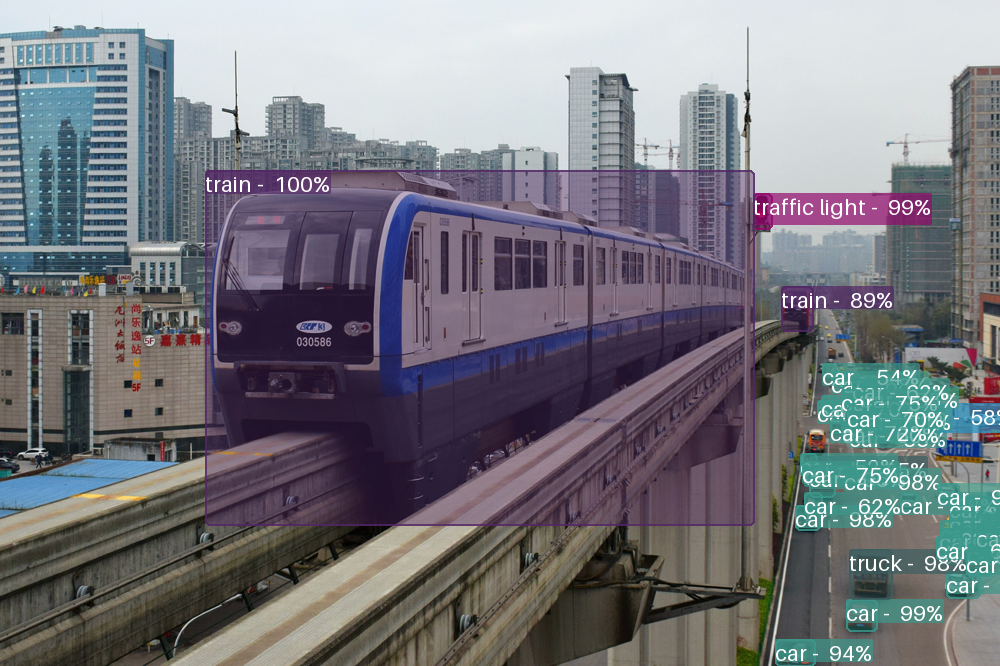

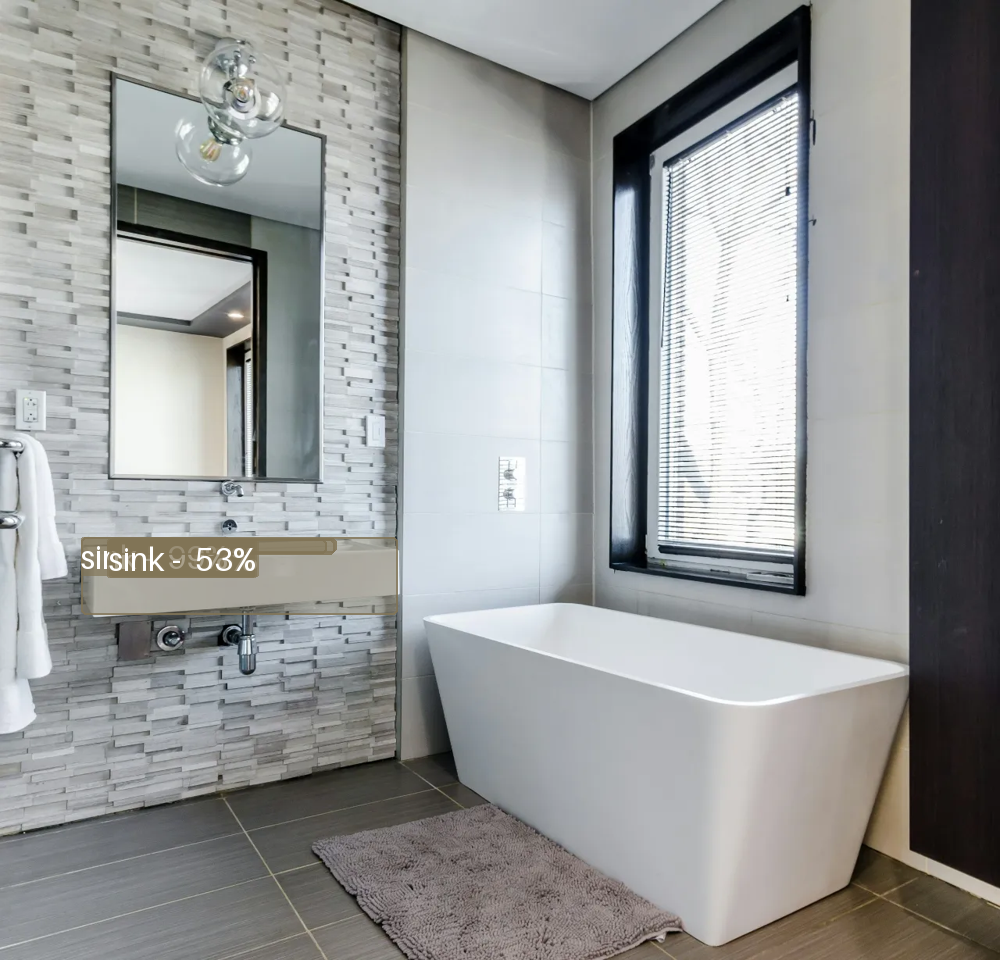

In [9]:
for model_result, image in zip(model_results, input_images):
    visualize_object_predictions(
        img=image,
        model_result=model_result,
        class_id_to_label=detr_model.config.id2label,  # pyright: ignore
        display_result=True,
    )